In [1]:
import cftime
import pandas as pd
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from scipy.ndimage import label
from pathlib import Path
import pyarrow as pa
from collections import Counter
import regionmask
import matplotlib.patheffects as path_effects 
import cartopy.io.shapereader as shpreader
import seaborn as sns
from scipy import stats

# Ticks and Plot Features

In [2]:
import numpy as np

def generate_custom_ticks_1(grid_values):
    # 1. Get exact data limits
    exact_min = np.nanmin(grid_values)
    exact_max = np.nanmax(grid_values)
    
    if np.isnan(exact_min): 
        exact_min, exact_max = -7.0, 7.0
        
    # 2. Find the largest absolute value to force symmetry around 0
    max_abs = int(np.ceil(max(abs(exact_min), abs(exact_max))))
    
    # Force a minimum symmetric boundary (e.g., if max change is only 1, force a clean map)
    if max_abs == 0: 
        max_abs = 1
        
    # 3. Establish symmetric exact visual boundaries for pcolormesh (vmin / vmax)
    exact_min_sym = -max_abs
    exact_max_sym = max_abs
    
    # 4. Generate whole-number ticks from -max_abs to +max_abs
    # We step by 1 or 2 depending on how wide the span is to keep the colorbar clean
    step = 1
    custom_ticks = list(range(-max_abs, max_abs + 1, step))
    
    # 5. Create clean string labels without decimal points
    tick_labels = [f"{t}" for t in custom_ticks]
    
    return custom_ticks, tick_labels, exact_max_sym, exact_min_sym

In [3]:
import numpy as np

def generate_custom_ticks_05(grid_values):
    # 1. Get exact data limits
    exact_min = np.nanmin(grid_values)
    exact_max = np.nanmax(grid_values)
    
    if np.isnan(exact_min): exact_min, exact_max = 0.0, 2.0
    
    # 2. Round outward to the nearest 0.5 step to establish the uniform grid
    grid_start = np.floor(exact_min * 2) / 2
    grid_end = np.ceil(exact_max * 2) / 2
    
    # 3. Generate the full uniform step array (inclusive of grid_end)
    full_grid = np.arange(grid_start, grid_end + 0.1, 0.5)
    
    # 4. Slice off the fake outer boundaries to leave only the true middle ticks
    middle_ticks = list(full_grid[1:-1])
    
    # 5. Group together: [Exact Min, Middle Ticks..., Exact Max]
    custom_ticks = middle_ticks
    
    # 6. Generate text labels matching the spacing rules
    tick_labels = []
    for t in middle_ticks:
        if t % 1 == 0:
            tick_labels.append(f"{t:.1f}") # Pure whole numbers get no decimals
        else:
            tick_labels.append(f"{t:.1f}")  # Half-steps get 1 decimal place (e.g., 2.5)
            
    return custom_ticks, tick_labels, exact_max, exact_min

In [4]:
import numpy as np

def generate_custom_ticks_02(grid_values):
    # 1. Get exact data limits
    exact_max = np.nanmax(grid_values)
    
    # 2. Round outward to the nearest 0.5 step to establish the uniform grid
    grid_start = np.floor(-exact_max * 2) / 2
    grid_end = np.ceil(exact_max * 2) / 2
    
    # 3. Generate the full uniform step array (inclusive of grid_end)
    full_grid = np.arange(grid_start, grid_end + 0.1, .1)
    
    # 4. Slice off the fake outer boundaries to leave only the true middle ticks
    middle_ticks = list(full_grid[1:-1])
    
    # 5. Group together: [Exact Min, Middle Ticks..., Exact Max]
    custom_ticks = [-exact_max] + middle_ticks + [exact_max]
    
    # 6. Generate text labels matching the spacing rules
    tick_labels = []
    for t in custom_ticks:
        if t % 1 == 0:
            tick_labels.append(f"{t:.1f}") # Pure whole numbers get no decimals
        else:
            tick_labels.append(f"{t:.1f}")  # Half-steps get 1 decimal place (e.g., 2.5)
            
    return custom_ticks, tick_labels, exact_max, -exact_max

In [5]:

# --- STEP 1: Load Canada and Mexico Geometries once ---
shpfilename = shpreader.natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
records = reader.records()

canada_geom = None
mexico_geom = None

for record in records:
    country_name = record.attributes.get('NAME')
    if country_name == 'Canada':
        canada_geom = record.geometry
    elif country_name == 'Mexico':
        mexico_geom = record.geometry

# Load 50m Lakes Shapefile from Natural Earth
lakes_shp = shpreader.natural_earth(resolution='50m', category='physical', name='lakes')
lakes_reader = shpreader.Reader(lakes_shp)

# Names of the Great Lakes to isolate
great_lakes_names = {'Lake Superior', 'Lake Michigan', 'Lake Huron', 'Lake Erie', 'Lake Ontario'}

# Filter out only the Great Lakes geometries
great_lakes_geoms = []
for record in lakes_reader.records():
    # 'name' is the attribute key for the lake's name in Natural Earth
    lake_name = record.attributes.get('name')
    if lake_name in great_lakes_names:
        great_lakes_geoms.append(record.geometry)

# Use Natural Earth's defined regions for US States (50m resolution)
us_states = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50


# HIST/FTR Thirstwave File

In [6]:
# Define file paths
hist = '/data1/michsh/CSV/HIST_derived_metrics_2.csv'
ftr = '/data1/michsh/CSV/FUT_derived_metrics_2.csv'

# Thirstwave Characteristics HIST/FTR AVG

## Frequency

### How many TW's happen per growing season across the CONUS. Purge the data values from Mexico, Canada, and oceans. CONUS definded by any gridbox thats within the coastline of the US. 

In [7]:
frq_chunks_hist = []
frq_chunks_ftr = []

# Load annual freqeuncy for each member, lat, lon, and year.
for frq_chunk_hist in pd.read_csv(hist, chunksize=500000):
    grouped_frq_chunk_hist = (
        frq_chunk_hist
        .groupby(['AMOC', 'member', 'lat', 'lon', 'year'])['annual_frequency']
        .first()
        .reset_index()
    )
    frq_chunks_hist.append(grouped_frq_chunk_hist)

for frq_chunk_ftr in pd.read_csv(ftr, chunksize=500000):
    grouped_frq_chunk_ftr = (
        frq_chunk_ftr
        .groupby(['AMOC', 'member', 'lat', 'lon', 'year'])['annual_frequency']
        .first()
        .reset_index()
    )
    frq_chunks_ftr.append(grouped_frq_chunk_ftr)

# This code reads a large CSV file for both HIST/FTR datasets in manageable chunks of 
# 500,000 rows to avoid exhausting system memory. 
# For each chunk, the data are grouped by AMOC state, ensemble member, latitude, longitude, and year, 
# the first annual frequency value associated with each unique combination is retained. 
# The resulting aggregated subset is then prepared for storage in a list, 
# allowing all chunks to be combined later for subsequent analysis. 

In [8]:
df_frq_yearly_hist = (
    pd.concat(frq_chunks_hist)
    .groupby(['AMOC', 'member', 'lat', 'lon', 'year'])['annual_frequency']
    .first()
    .reset_index()
)

df_frq_yearly_ftr = (
    pd.concat(frq_chunks_ftr)
    .groupby(['AMOC', 'member', 'lat', 'lon', 'year'])['annual_frequency']
    .first()
    .reset_index()
)

# This code combines all previously processed historical data chunks into a single DataFrame 
# and groups the records by AMOC state, ensemble member, latitude, longitude, and year. 
# It aims to get rid of duplicate rows. 

In [9]:
all_years_hist = list(range(1850,2014+1))
all_years_ftr = list(range(2015,2100+1))

# Create list of years to restructure the years in the frq dataset.
# Need ot account for years without a thristwave.
# Could allow us to get % of years without thristwave. 

# Historical Calculation workflow -------------------------------------------------
# This code pivots the index into an excel spreadsheet and fills in years that have no value for frq. 
df_years_reindex_hist = (
    df_frq_yearly_hist
    .pivot(
        index=['AMOC', 'member', 'lat', 'lon'],
        columns='year',
        values='annual_frequency'
    )
    .fillna(0)
    .reindex(
        columns=all_years_hist, 
        fill_value=0
    )
)

# Mean across years -> one value per member/gridpoint
# creates an index of one value per member per gridpoint
hist_member_means_frq = ( # <-------------------------------------- Important for Histograms and showing tails of it
    df_years_reindex_hist
    .mean(axis=1)
    .reset_index(name='mean_annual_frequency')
)

# Mean across all 80 members
# Created an ensemble avg across members for each gridpoint. 
hist_ensemble_mean_frq = (
    hist_member_means_frq
    .groupby(['lat', 'lon'])['mean_annual_frequency']
    .mean()
    .reset_index()
)

# Future Workflow ---------------------------------------------------------------------
df_years_reindex_ftr = (
    df_frq_yearly_ftr
    .pivot(
        index=['AMOC', 'member', 'lat', 'lon'],
        columns='year',
        values='annual_frequency'
    )
    .fillna(0)
    .reindex(
        columns=all_years_ftr, 
        fill_value=0
    )
)

ftr_member_means_frq = (
    df_years_reindex_ftr
    .mean(axis=1)
    .reset_index(name='mean_annual_frequency')
)

ftr_ensemble_mean_frq = (
    ftr_member_means_frq
    .groupby(['lat', 'lon'])['mean_annual_frequency']
    .mean()
    .reset_index()
)

In [21]:
import pandas as pd


def get_conus_mask_df(df, us_states_obj):
    """Generates a DataFrame of valid CONUS lat/lon coordinates from a dataset."""
    lats = df["lat"].unique()
    lons = df["lon"].unique()

    # Generate 3D Fractional CONUS Mask & collapse to 2D
    frac_mask_3d = us_states_obj.mask_3D_frac_approx(lons, lats, wrap_lon=True)
    any_overlap_mask = (frac_mask_3d > 0).any(dim="region")

    # Return unique lat/lon pairs inside CONUS
    return (
        any_overlap_mask.to_dataframe(name="is_conus")
        .query("is_conus == True")
        .reset_index()[["lat", "lon"]]
    )


def slice_spatial_box(df, s=None, n=None, w=None, e=None, conus_mask_df=None):
    """Filters a DataFrame by latitude/longitude bounds and/or a CONUS shape mask."""
    # Start with full copy or CONUS-masked subset
    if conus_mask_df is not None:
        filtered_df = pd.merge(
            df, conus_mask_df, on=["lat", "lon"], how="inner"
        )
    else:
        filtered_df = df.copy()

    # If no spatial box bounds are specified, return the current masked DataFrame
    if s is None or n is None or w is None or e is None:
        return filtered_df

    # Apply bounding box filtering for sub-regions
    w_neg, e_neg = -abs(w), -abs(e)
    w_360, e_360 = w_neg % 360, e_neg % 360

    lat_mask = (filtered_df["lat"] >= s) & (filtered_df["lat"] <= n)
    lon_mask = ((filtered_df["lon"] >= w_neg) & (filtered_df["lon"] <= e_neg)) | (
        (filtered_df["lon"] >= w_360) & (filtered_df["lon"] <= e_360)
    )

    return filtered_df[lat_mask & lon_mask].copy()


# =========================================================================
# 1. PRE-COMPUTE CONUS MASK
# =========================================================================
# Generate CONUS coordinates grid using historical grid structure
conus_coords_df = get_conus_mask_df(hist_ensemble_mean_frq, us_states)


# =========================================================================
# 2. DEFINE REGIONS CONFIGURATION
# =========================================================================
regions = [
    {
        "name": "CONUS",
        "lat_s": None,
        "lat_n": None,
        "lon_w": None,
        "lon_e": None,
        "use_conus_mask": True,
    },
    {
        "name": "Midwest",
        "lat_s": 39,
        "lat_n": 47,
        "lon_w": -103,
        "lon_e": -89,
        "use_conus_mask": True,  # Set to True if you also want Midwest constrained strictly to CONUS land
    },
    {
        "name": "Northeast",
        "lat_s": 40,
        "lat_n": 45,
        "lon_w": -80,
        "lon_e": -70,
        "use_conus_mask": True,
    },
]


# =========================================================================
# 3. CALCULATE AND PRINT REGIONAL ENSEMBLE MEANS & % CHANGE
# =========================================================================
for reg in regions:
    region_name = reg["name"]
    mask_to_use = conus_coords_df if reg.get("use_conus_mask") else None

    # Slice grid-cell ensemble averages for the region
    hist_reg_df = slice_spatial_box(
        hist_ensemble_mean_frq,
        reg["lat_s"],
        reg["lat_n"],
        reg["lon_w"],
        reg["lon_e"],
        conus_mask_df=mask_to_use,
    )

    ftr_reg_df = slice_spatial_box(
        ftr_ensemble_mean_frq,
        reg["lat_s"],
        reg["lat_n"],
        reg["lon_w"],
        reg["lon_e"],
        conus_mask_df=mask_to_use,
    )

    # Calculate scalar spatial mean across grid boxes in the region
    reg_hist_mean = hist_reg_df["mean_annual_frequency"].mean()
    reg_ftr_mean = ftr_reg_df["mean_annual_frequency"].mean()

    # Calculate absolute difference (Delta) and Percentage Change
    reg_delta_mean = reg_ftr_mean - reg_hist_mean

    reg_pct_change = (
        (reg_delta_mean / reg_hist_mean) * 100 if reg_hist_mean != 0 else 0.0
    )

    # Print summary output for the current region
    print(f"{'='*60}")
    print(f" REGION: {region_name.upper()}")
    print(f"{'='*60}")
    print(
        f"  Historical Ensemble Mean Frequency: {reg_hist_mean:.4f} Events"
    )
    print(
        f"  Future Ensemble Mean Frequency:     {reg_ftr_mean:.4f} Events"
    )
    print(
        f"  Net Mean Frequency Change (Delta):  {reg_delta_mean:+.4f} Events"
    )
    print(f"  Percentage Change:                  {reg_pct_change:+.2f}%\n")

 REGION: CONUS
  Historical Ensemble Mean Frequency: 1.8966 Events
  Future Ensemble Mean Frequency:     5.3181 Events
  Net Mean Frequency Change (Delta):  +3.4215 Events
  Percentage Change:                  +180.40%

 REGION: MIDWEST
  Historical Ensemble Mean Frequency: 1.8265 Events
  Future Ensemble Mean Frequency:     4.4492 Events
  Net Mean Frequency Change (Delta):  +2.6228 Events
  Percentage Change:                  +143.60%

 REGION: NORTHEAST
  Historical Ensemble Mean Frequency: 1.4963 Events
  Future Ensemble Mean Frequency:     7.2015 Events
  Net Mean Frequency Change (Delta):  +5.7052 Events
  Percentage Change:                  +381.28%



## Frequency: Ensemble CONUS AVG Plots

In [10]:
# CONUS ENSEMBLE AVG PLOTING CODE ===========================================================

masked_data_arrays = []
for df in [hist_ensemble_mean_frq, ftr_ensemble_mean_frq]:
    lats = df['lat'].unique()
    lons = df['lon'].unique()
    
    # 1. Calculate fractional overlap
    frac_mask_3d = us_states.mask_3D_frac_approx(lons, lats, wrap_lon=True)
    
    # 2. Collapse region dimension
    any_overlap_mask = (frac_mask_3d > 0).any(dim="region")
    
    # 3. Pivot spatial coordinates
    pivoted = df.pivot(index='lat', columns='lon', values='mean_annual_frequency')
    
    # 4. Mask spatial points
    pivoted_masked = pivoted.where(any_overlap_mask.values)
    
    # 5. Unstack with future_stack=True to eliminate the warning
    flat_masked = (
        pivoted_masked
        .stack(future_stack=True) # Removed dropna=True
        .dropna()                  # Drop the NaN values created by the region mask
        .reset_index(name='mean_annual_frequency')
    )
    masked_data_arrays.append(flat_masked)

hist_conus_mean_masked, ftr_conus_mean_masked = masked_data_arrays

# Pivot to grided data
hist_conus_mean_masked_grid = (
        hist_conus_mean_masked
        .pivot(index='lat', columns='lon', values='mean_annual_frequency')
        .sort_index(ascending=True)         # Sort Latitudes monotonically
        .sort_index(axis=1, ascending=True) # Sort Longitudes monotonically
    )

ftr_conus_mean_masked_grid = (
        ftr_conus_mean_masked
        .pivot(index='lat', columns='lon', values='mean_annual_frequency')
        .sort_index(ascending=True)         # Sort Latitudes monotonically
        .sort_index(axis=1, ascending=True) # Sort Longitudes monotonically
    )

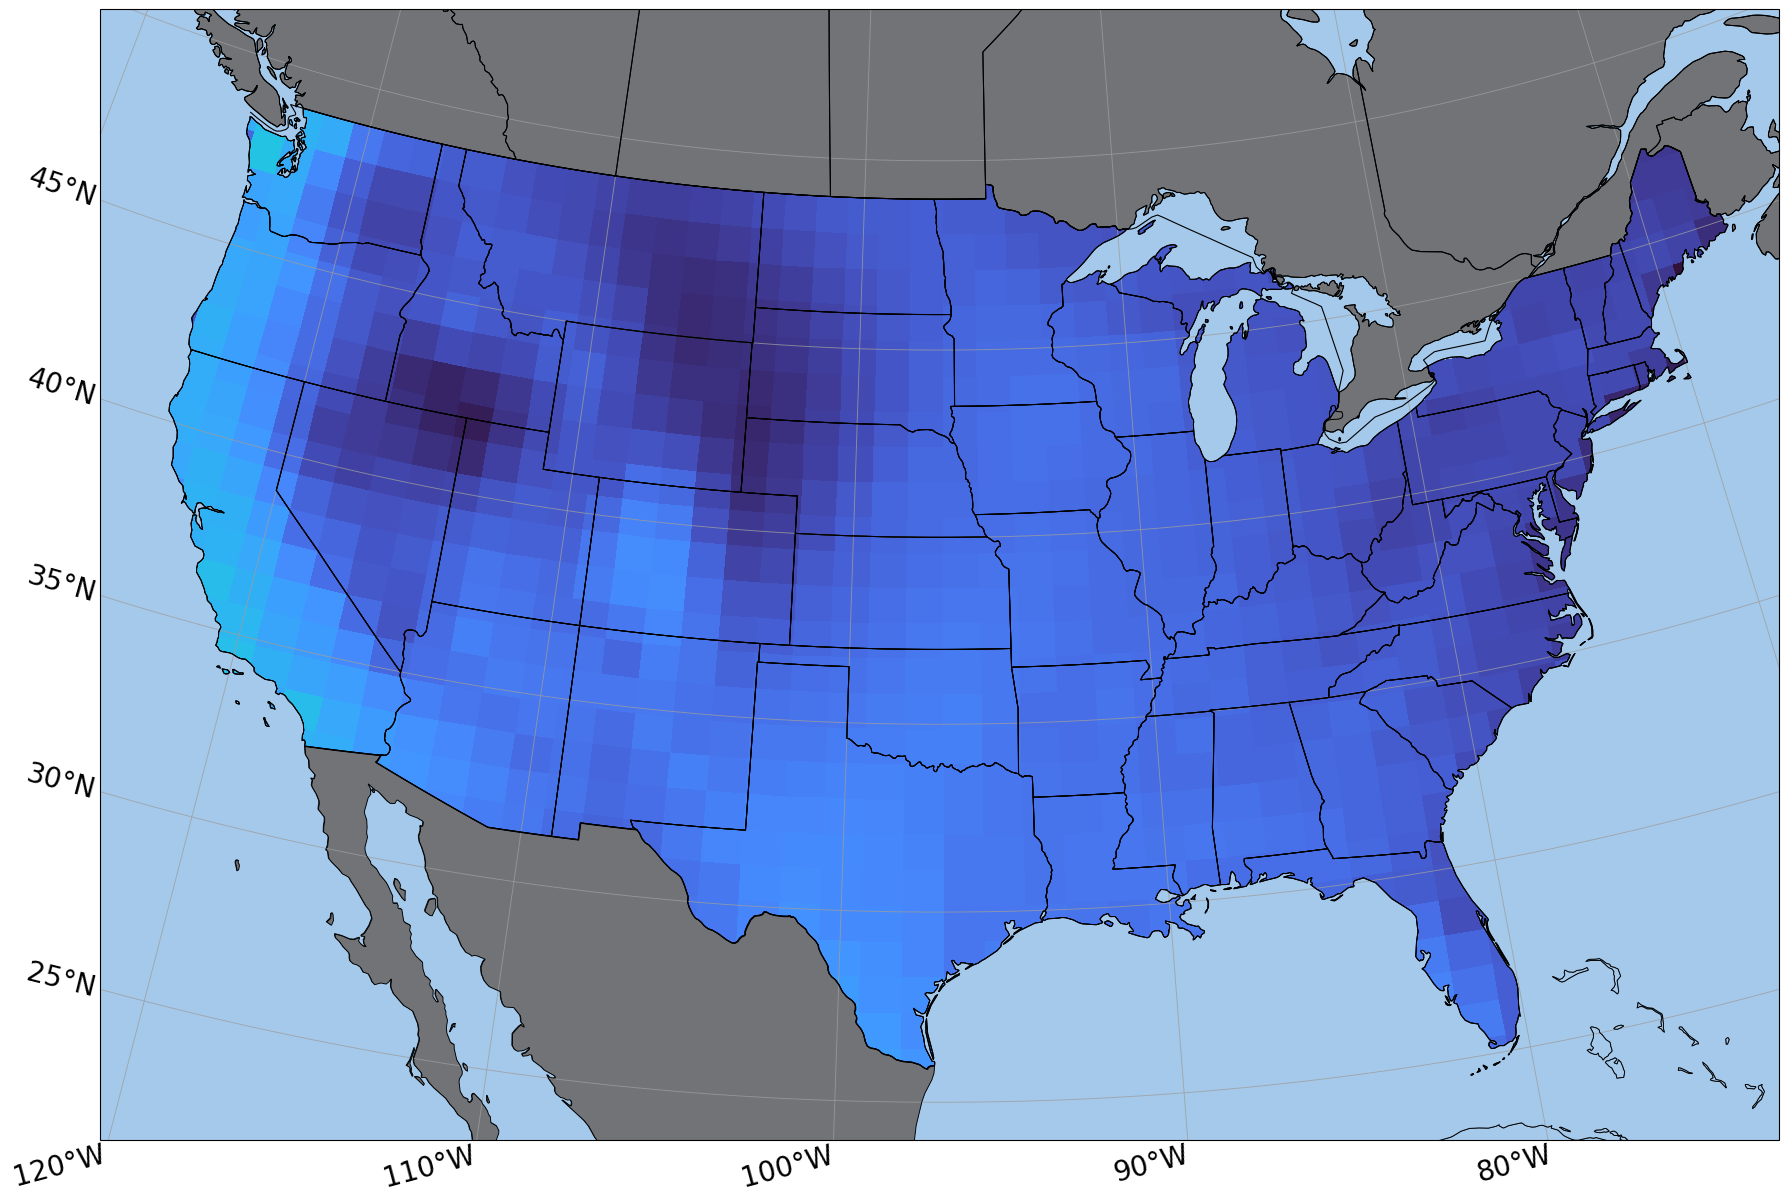

In [11]:
grided_data = [hist_conus_mean_masked_grid]

global_min = min(hist_conus_mean_masked['mean_annual_frequency'].min(), ftr_conus_mean_masked['mean_annual_frequency'].min())
global_max = max(hist_conus_mean_masked['mean_annual_frequency'].max(), ftr_conus_mean_masked['mean_annual_frequency'].max())

combined_min_max_grid = np.array([global_min, global_max])
custom_ticks, tick_labels, exact_max, exact_min = generate_custom_ticks_05(combined_min_max_grid)

for grid in grided_data: 

    if grid is hist_conus_mean_masked_grid:
        title = "Historical Thirstwave Frequency | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Frequency_Mean_HIST'
    elif grid is ftr_conus_mean_masked_grid:
        title = "Future Thirstwave Frequency | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Frequency_Mean_FTR'

    # Create Meshgrid from sorted 1D coordinates
    X, Y = np.meshgrid(grid.columns, grid.index)

    s_lat, n_lat = 24, 52
    w_lon, e_lon = -121, -73

    crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

    fig = plt.figure(figsize=(18, 16))
    ax = plt.axes(projection=crs)

    # Set map boundaries
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    water_color = '#a5c9eb'  # Soft pastel blue
    ax.set_facecolor(water_color)  

    im = ax.pcolormesh(X, Y, grid.values, 
                       transform=ccrs.PlateCarree(), 
                       cmap='turbo', # <==================================================================== COLORTABLE
                       vmin=exact_min, vmax=exact_max, 
                       shading='auto',
                       zorder=1)

    if canada_geom is not None:
        ax.add_geometries([canada_geom], crs=ccrs.PlateCarree(), 
                          facecolor='#717376', edgecolor='black', linewidth=0.65, zorder=2)
    if mexico_geom is not None:
        ax.add_geometries([mexico_geom], crs=ccrs.PlateCarree(), 
                          facecolor="#717376", edgecolor='black', linewidth=0.65, zorder=2)
    if great_lakes_geoms:
        ax.add_geometries(great_lakes_geoms, crs=ccrs.PlateCarree(),
                          facecolor=water_color, edgecolor='black', linewidth=0.65, zorder=2)

    # USA outer outline
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor=water_color, zorder=2)
    ax.coastlines('50m', linewidth=0.65, color='black', zorder=3)

    # USA outer outline
    usa_outline = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none',
        edgecolor='black',
        linewidth=0.8
    )
    ax.add_feature(usa_outline, zorder=3)

    # US State Boundaries
    states = cfeature.NaturalEarthFeature(
        category='cultural', 
        name='admin_1_states_provinces_lakes', 
        scale='50m', 
        facecolor='none'
    )
    ax.add_feature(states, edgecolor='black', linewidth=0.75, zorder=3)

    # Map features
    ax.coastlines('50m', linewidth=0.65)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.65)

        # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.65, 
                      color="#9d9d9d", zorder= 4, alpha=0.8)

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # --- ADDED: Set padding (in points) between labels and the map frame ---
    gl.xpadding = 4  # Adds space for bottom (longitude) labels
    gl.ypadding = 4  # Adds space for left (latitude) labels

    # Style the labels (removed the non-standard 'pad' key)
    gl.xlabel_style = {'size': 20, 'color': 'black', 'rotation': 15}
    gl.ylabel_style = {'size': 20, 'color': 'black'}

    # Force clean tick intervals
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))
    
    # ax_box = ax.inset_axes([0.90, 0, 0.10, 0.55], zorder=5)
    # ax_box.set_facecolor('white')
    # ax_box.set_xticks([])
    # ax_box.set_yticks([])
    # for spine in ax_box.spines.values():
    #     spine.set_visible(True)
    #     spine.set_edgecolor('black')
    #     spine.set_linewidth(1.0)

    # # Adjusted to end at y=0.78, leaving the top 22% of the white box for the title
    # # Pushed to x=0.20 to leave plenty of room on the right side for tick labels
    # cax = ax_box.inset_axes([0.10, 0.04, 0.49, 0.84]) 

    # # Plot vertical colorbar (Notice: cb.ax.set_title was removed!)
    # cb = plt.colorbar(im, cax=cax, orientation='vertical', ticks=custom_ticks) 

    # # Style the colorbar ticks & tick labels
    # cb.ax.set_yticklabels(tick_labels, fontsize=18, color='black')
    # cb.ax.tick_params(direction='out', length=4, width=1)

    # # --- ADDED: Text Title inside the White Box ---
    # # Centered at x=0.5 (middle of the box) and y=0.89 (near the top)
    # ax_box.text(
    #     0.5, 0.94, 
    #     "Events", 
    #     transform=ax_box.transAxes, 
    #     fontsize=20, 
    #     weight='bold', 
    #     color='black',
    #     ha='center', 
    #     va='center'
    # )

    # Title & Layout rendering
    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()  

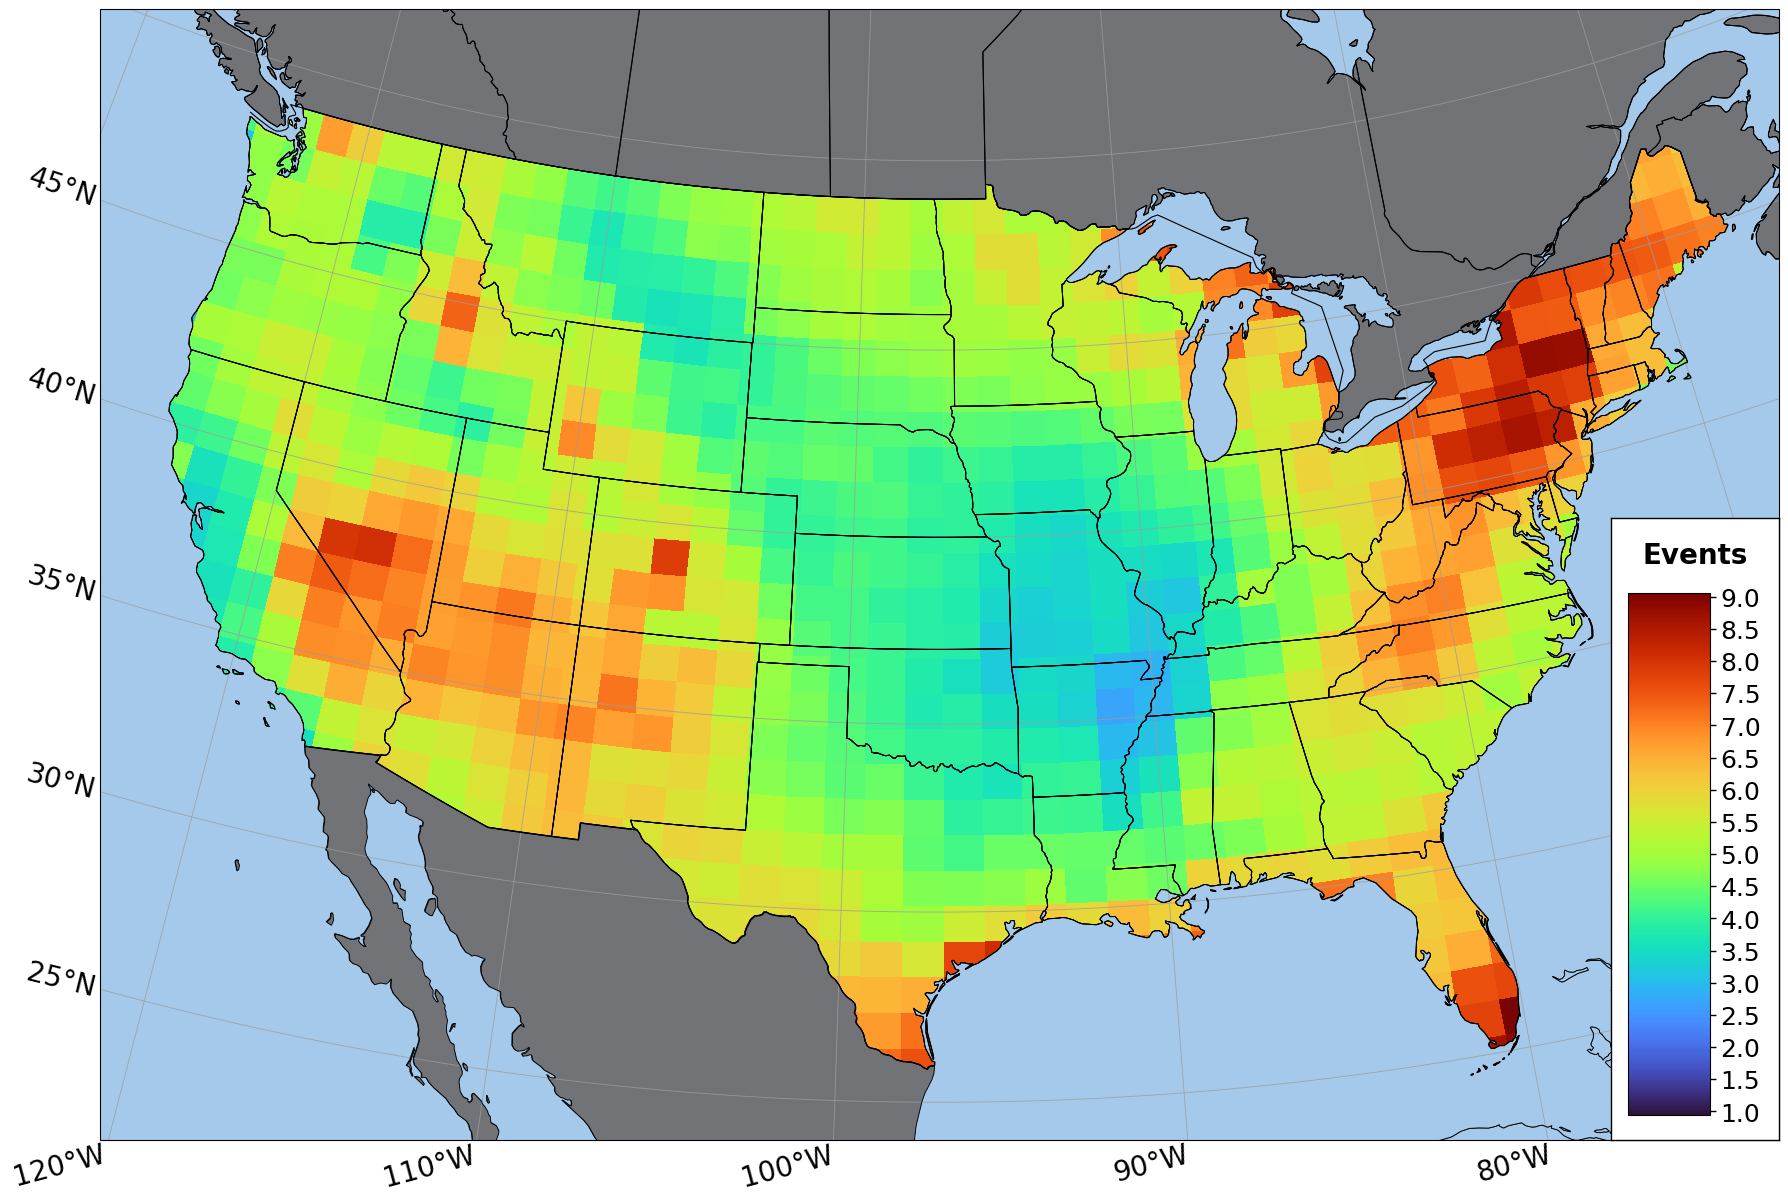

In [12]:
grided_data = [ftr_conus_mean_masked_grid]

global_min = min(hist_conus_mean_masked['mean_annual_frequency'].min(), ftr_conus_mean_masked['mean_annual_frequency'].min())
global_max = max(hist_conus_mean_masked['mean_annual_frequency'].max(), ftr_conus_mean_masked['mean_annual_frequency'].max())

combined_min_max_grid = np.array([global_min, global_max])
custom_ticks, tick_labels, exact_max, exact_min = generate_custom_ticks_05(combined_min_max_grid)

for grid in grided_data: 

    if grid is hist_conus_mean_masked_grid:
        title = "Historical Thirstwave Frequency | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Frequency_Mean_HIST'
    elif grid is ftr_conus_mean_masked_grid:
        title = "Future Thirstwave Frequency | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Frequency_Mean_FTR'

    # Create Meshgrid from sorted 1D coordinates
    X, Y = np.meshgrid(grid.columns, grid.index)

    s_lat, n_lat = 24, 52
    w_lon, e_lon = -121, -73

    crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

    fig = plt.figure(figsize=(18, 16))
    ax = plt.axes(projection=crs)

    # Set map boundaries
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    water_color = '#a5c9eb'  # Soft pastel blue
    ax.set_facecolor(water_color)  

    im = ax.pcolormesh(X, Y, grid.values, 
                       transform=ccrs.PlateCarree(), 
                       cmap='turbo', # <==================================================================== COLORTABLE
                       vmin=exact_min, vmax=exact_max, 
                       shading='auto',
                       zorder=1)

    if canada_geom is not None:
        ax.add_geometries([canada_geom], crs=ccrs.PlateCarree(), 
                          facecolor='#717376', edgecolor='black', linewidth=0.65, zorder=2)
    if mexico_geom is not None:
        ax.add_geometries([mexico_geom], crs=ccrs.PlateCarree(), 
                          facecolor="#717376", edgecolor='black', linewidth=0.65, zorder=2)
    if great_lakes_geoms:
        ax.add_geometries(great_lakes_geoms, crs=ccrs.PlateCarree(),
                          facecolor=water_color, edgecolor='black', linewidth=0.65, zorder=2)

    # USA outer outline
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor=water_color, zorder=2)
    ax.coastlines('50m', linewidth=0.65, color='black', zorder=3)

    # USA outer outline
    usa_outline = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none',
        edgecolor='black',
        linewidth=0.8
    )
    ax.add_feature(usa_outline, zorder=3)

    # US State Boundaries
    states = cfeature.NaturalEarthFeature(
        category='cultural', 
        name='admin_1_states_provinces_lakes', 
        scale='50m', 
        facecolor='none'
    )
    ax.add_feature(states, edgecolor='black', linewidth=0.75, zorder=3)

    # Map features
    ax.coastlines('50m', linewidth=0.65)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.65)

        # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.65, 
                      color="#9d9d9d", zorder= 4, alpha=0.8)

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # --- ADDED: Set padding (in points) between labels and the map frame ---
    gl.xpadding = 4  # Adds space for bottom (longitude) labels
    gl.ypadding = 4  # Adds space for left (latitude) labels

    # Style the labels (removed the non-standard 'pad' key)
    gl.xlabel_style = {'size': 20, 'color': 'black', 'rotation': 15}
    gl.ylabel_style = {'size': 20, 'color': 'black'}

    # Force clean tick intervals
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))
    
    ax_box = ax.inset_axes([0.90, 0, 0.10, 0.55], zorder=5)
    ax_box.set_facecolor('white')
    ax_box.set_xticks([])
    ax_box.set_yticks([])
    for spine in ax_box.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

    # Adjusted to end at y=0.78, leaving the top 22% of the white box for the title
    # Pushed to x=0.20 to leave plenty of room on the right side for tick labels
    cax = ax_box.inset_axes([0.10, 0.04, 0.49, 0.84]) 

    # Plot vertical colorbar (Notice: cb.ax.set_title was removed!)
    cb = plt.colorbar(im, cax=cax, orientation='vertical', ticks=custom_ticks) 

    # Style the colorbar ticks & tick labels
    cb.ax.set_yticklabels(tick_labels, fontsize=18, color='black')
    cb.ax.tick_params(direction='out', length=4, width=1)

    # --- ADDED: Text Title inside the White Box ---
    # Centered at x=0.5 (middle of the box) and y=0.89 (near the top)
    ax_box.text(
        0.5, 0.94, 
        "Events", 
        transform=ax_box.transAxes, 
        fontsize=20, 
        weight='bold', 
        color='black',
        ha='center', 
        va='center'
    )

    # Title & Layout rendering
    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()  

## Frequency: Pooled T-Test and Delta Plots

In [13]:
# Get all unique spatial grid cells
frq_gridboxes = hist_member_means_frq[['lat', 'lon']].drop_duplicates()
frq_results = []

# Loop through each lat/lon gridbox explicitly
for row in frq_gridboxes.itertuples():
    lat = row.lat
    lon = row.lon

    # Extract all ensemble members for this specific lat/lon
    frq_hist_subset = hist_member_means_frq[
        (hist_member_means_frq.lat == lat) & (hist_member_means_frq.lon == lon)
    ]
    frq_ftr_subset = ftr_member_means_frq[
        (ftr_member_means_frq.lat == lat) & (ftr_member_means_frq.lon == lon)
    ]

    frq_hist_values = frq_hist_subset['mean_annual_frequency'].values
    frq_ftr_values = frq_ftr_subset['mean_annual_frequency'].values

    # Run independent t-test across ensemble members
    frq_t_stat, frq_p_value = stats.ttest_ind(
        frq_ftr_values,
        frq_hist_values,
        equal_var=True,
        alternative='greater',
        nan_policy='omit'
    )

    # Calculate difference between future mean and historical mean
    frq_delta_value = np.nanmean(frq_ftr_values) - np.nanmean(frq_hist_values)

    frq_results.append([lat, lon, frq_p_value, frq_delta_value])

# Create a flat DataFrame of results
frq_results_df = pd.DataFrame(frq_results, columns=['lat', 'lon', 'p_value', 'delta'])

# Pivot into lat x lon matrices
frq_p_values_grid = frq_results_df.pivot(index='lat', columns='lon', values='p_value')
frq_delta_grid = frq_results_df.pivot(index='lat', columns='lon', values='delta')

# Build CONUS mask matching the unique coordinates
frq_lats = frq_p_values_grid.index.values
frq_lons = frq_p_values_grid.columns.values

frac_mask_3d = us_states.mask_3D_frac_approx(frq_lons, frq_lats, wrap_lon=True)
any_overlap_mask = (frac_mask_3d > 0).any(dim="region")

# Mask both grids to CONUS
frq_p_values_mask = frq_p_values_grid.where(any_overlap_mask.values)
frq_delta_mask = frq_delta_grid.where(any_overlap_mask.values)

# Unstack back to flat DataFrames if needed for plotting or copy-pasting
frq_p_values_conus_flat = (
    frq_p_values_mask
    .stack(future_stack=True)
    .dropna()
    .reset_index(name='p_value')
)

frq_delta_conus_flat = (
    frq_delta_mask
    .stack(future_stack=True)
    .dropna()
    .reset_index(name='delta')
)

# Percentage of CONUS grid cells with significant increase (p < 0.05)
total_conus_cells = frq_p_values_mask.notna().sum().sum()
significant_conus_cells = (frq_p_values_mask < 0.05).sum().sum()

sig_pct = (significant_conus_cells / total_conus_cells) * 100
print(f"Percentage of CONUS showing significant increase (p < 0.05): {sig_pct:.2f}%")

Percentage of CONUS showing significant increase (p < 0.05): 100.00%


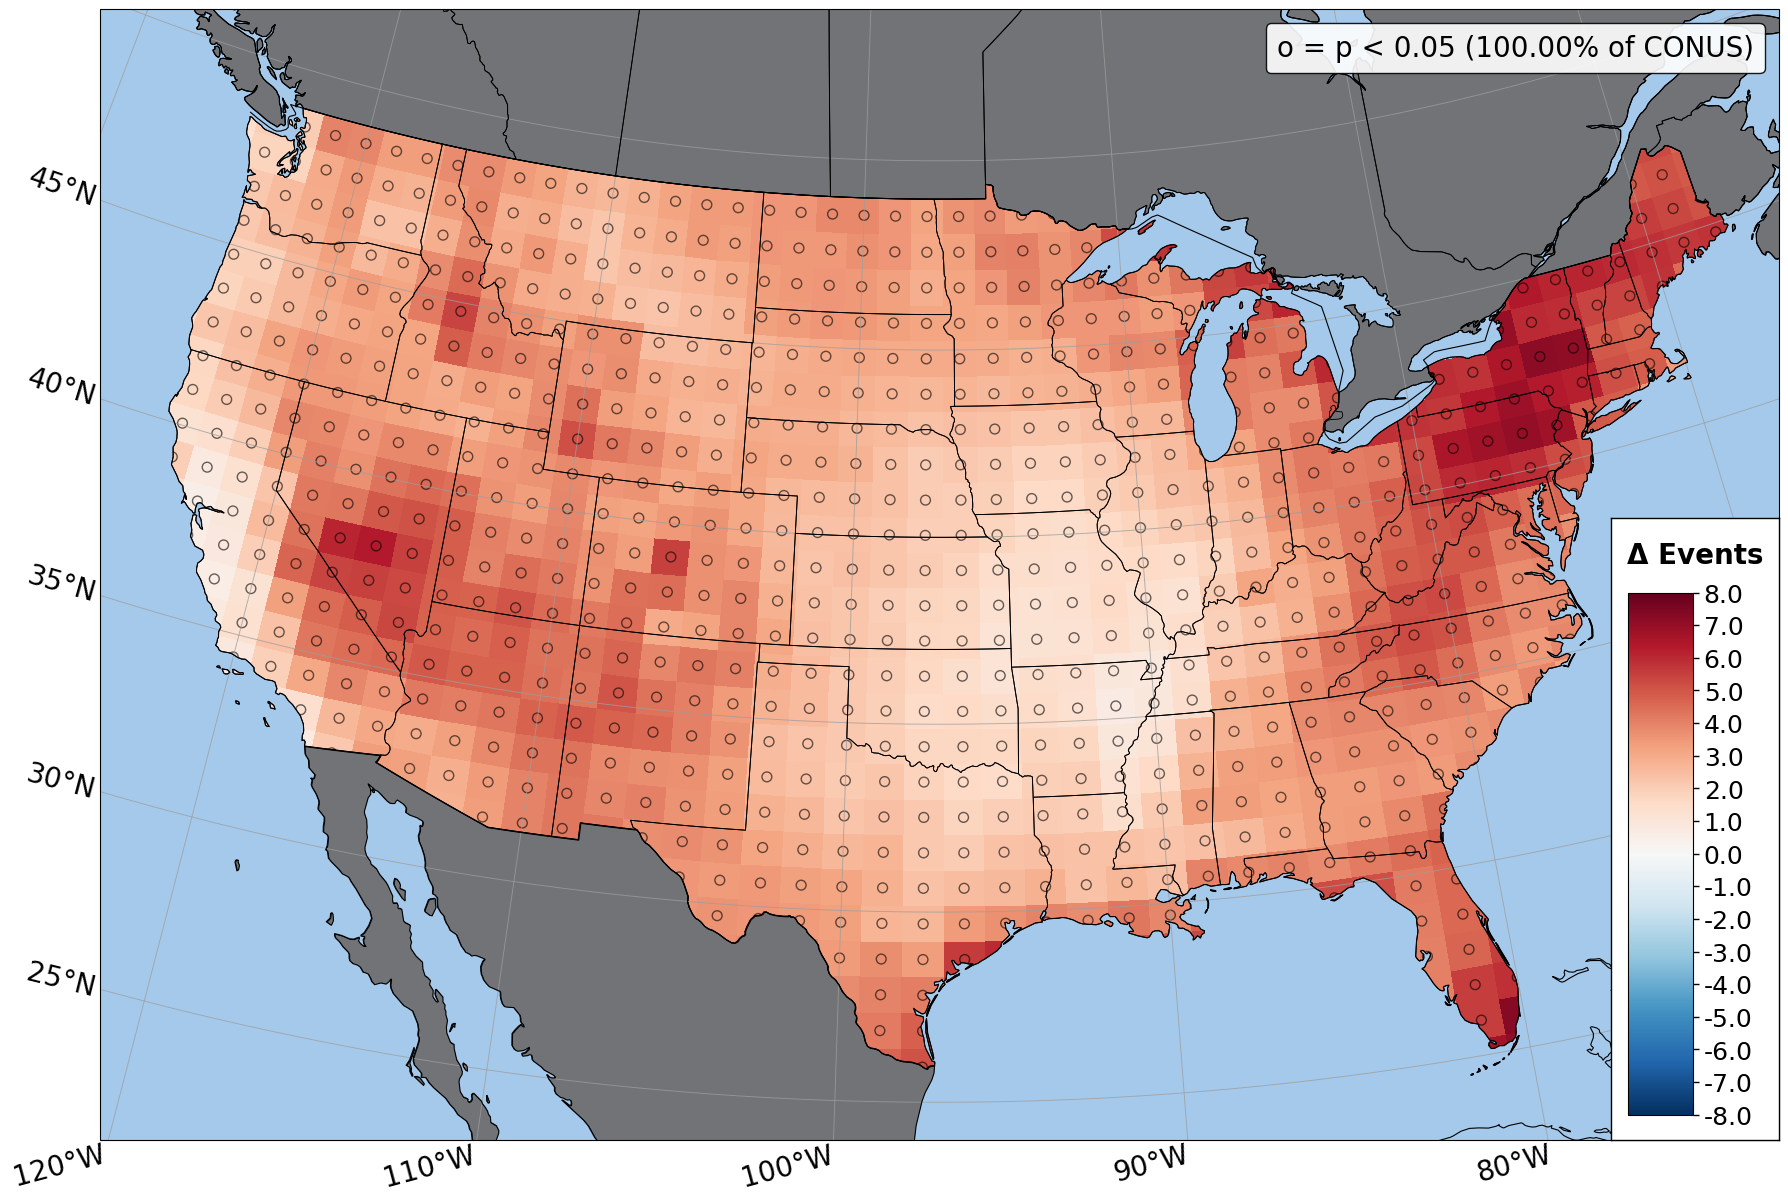

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

def generate_custom_ticks_1(grid_values, step=1):
    """
    Computes exact data min/max within CONUS, symmetric limits for pcolormesh,
    and ticks spaced by the step size, returning values expected by the script.
    """
    exact_min = float(np.nanmin(grid_values))
    exact_max = float(np.nanmax(grid_values))
    
    if np.isnan(exact_min): 
        exact_min, exact_max = -1.0, 1.0
        
    # Symmetric limits rounded up to the nearest multiple of 'step'
    max_abs = np.ceil(max(abs(exact_min), abs(exact_max)) / step) * step
    if max_abs == 0:
        max_abs = step
        
    exact_min_sym = -max_abs
    exact_max_sym = max_abs
    
    # Generate potential ticks based on step increment across full symmetric range
    num_steps = int(np.round((exact_max_sym - exact_min_sym) / step)) + 1
    custom_ticks = np.round(np.linspace(exact_min_sym, exact_max_sym, num_steps), 2)
    
    # Ensure 0.0 is explicitly included and clean up float precision
    custom_ticks = sorted(list(np.unique(np.round(custom_ticks, 2))))
    tick_labels = [f"{t:.1f}" for t in custom_ticks]
    
    # Returns 4 values expected by section #1: ticks, labels, max_limit, min_limit
    return custom_ticks, tick_labels, exact_max_sym, exact_min_sym

# 1. Color bar ticks settings
frq_CONUS_max = np.nanmax(np.abs(frq_delta_mask.values))
frq_CONUS_min = -frq_CONUS_max

combined_min_max_grid = np.array([frq_CONUS_min, frq_CONUS_max])
custom_ticks, tick_labels, exact_max, exact_min = generate_custom_ticks_1(combined_min_max_grid)

alpha = 0.05

# 2. Statistically significant gridcells mask
stat_sig_mask = (frq_p_values_mask < alpha) & (frq_delta_mask > 0)

# Calculate what percentage of CONUS experienced significant change
total_conus_cells = frq_p_values_mask.notna().sum().sum()
significant_conus_cells = stat_sig_mask.sum().sum()

sig_pct = (significant_conus_cells / total_conus_cells) * 100

# 3. Coordinate Grids & Extracted Significant Scatter Points
X, Y = np.meshgrid(frq_delta_mask.columns, frq_delta_mask.index)

# Extract coordinates where stat_sig_mask is True
sig_y_indices, sig_x_indices = np.where(stat_sig_mask.values)
significant_lats = frq_delta_mask.index[sig_y_indices]
significant_lons = frq_delta_mask.columns[sig_x_indices]

s_lat, n_lat = 24, 52
w_lon, e_lon = -121, -73

crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

fig = plt.figure(figsize=(18, 16))
ax = plt.axes(projection=crs)

# Set map boundaries
ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

water_color = '#a5c9eb' 
ax.set_facecolor(water_color)  

# Plot the background physical change (delta)
im = ax.pcolormesh(X, Y, frq_delta_mask.values, 
                    transform=ccrs.PlateCarree(), 
                    cmap='RdBu_r', 
                    vmin=exact_min, vmax=exact_max, 
                    shading='auto',
                    zorder=1)

if canada_geom is not None:
    ax.add_geometries([canada_geom], crs=ccrs.PlateCarree(), 
                        facecolor='#717376', edgecolor='black', linewidth=0.8, zorder=2)
if mexico_geom is not None:
    ax.add_geometries([mexico_geom], crs=ccrs.PlateCarree(), 
                        facecolor='#717376', edgecolor='black', linewidth=0.8, zorder=2)
if great_lakes_geoms:
    ax.add_geometries(great_lakes_geoms, crs=ccrs.PlateCarree(),
                        facecolor=water_color, edgecolor='black', linewidth=0.75, zorder=2)
    
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor=water_color, zorder=2)
ax.coastlines('50m', linewidth=0.8, color='black', zorder=4)

# USA outer outline
usa_outline = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none',
    edgecolor='black',
    linewidth=0.8,
    zorder=4
)
ax.add_feature(usa_outline, zorder=3)

# US State Boundaries
states = cfeature.NaturalEarthFeature(
    category='cultural', 
    name='admin_1_states_provinces_lakes', 
    scale='50m', 
    facecolor='none'
)
ax.add_feature(states, edgecolor='black', linewidth=0.65, zorder=4)

# Drawing gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.65, 
                    color="#9d9d9d", alpha=0.8, zorder=5)

gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.x_inline = False
gl.y_inline = False
gl.xpadding = 4  
gl.ypadding = 4  

gl.xlabel_style = {'size': 20, 'color': 'black', 'rotation': 15}
gl.ylabel_style = {'size': 20, 'color': 'black'}

gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

legend_label = f"o = p < 0.05 ({sig_pct:.2f}% of CONUS)"

proxy_handle = Line2D(
    [0], [0],
    color='none',
    linestyle='none',
    marker='none',
    label=legend_label
)

leg = ax.legend(
    handles=[proxy_handle],
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    framealpha=0.9, 
    edgecolor='black',
    fontsize=20,
    handlelength=0,
    handletextpad=0
)
leg.set_zorder(6)

# Colorbar Box Setup
ax_box = ax.inset_axes([0.90, 0, 0.10, 0.55], zorder=6)
ax_box.set_facecolor('white')
ax_box.set_xticks([])
ax_box.set_yticks([])
for spine in ax_box.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

cax = ax_box.inset_axes([0.10, 0.04, 0.39, 0.84]) 
cb = plt.colorbar(im, cax=cax, orientation='vertical', ticks=custom_ticks) 

cb.ax.set_yticklabels(tick_labels, fontsize=18, color='black')
cb.ax.tick_params(direction='out', length=4, width=1)

# Text Title inside the Colorbar Box
ax_box.text(
    0.5, 0.94, 
    'Δ Events', 
    transform=ax_box.transAxes, 
    fontsize=20, 
    weight='bold', 
    color='black',
    ha='center', 
    va='center'
)

# --- OVERLAY DELTA MARKERS (Stippling) ---
ax.scatter(significant_lons, significant_lats, 
            transform=ccrs.PlateCarree(),
            s=50,
            marker='o', 
            facecolors='none', 
            edgecolors='black', 
            alpha=0.6,
            zorder=1
        )

# Title strictly specifying p < 0.05
plt.tight_layout()

plt.savefig('Frequency_Mean_Delta_005', dpi=300, bbox_inches='tight')
plt.show()

### Frequency: Histograms

In [15]:
# Histogram Plotting Code ===========================================================
# Take raw values and add the zero column to then be ready for ploting and adjust eh percentages for freqeuncy per year. 
masked_data_arrays = []

# Define list of years for each dataset
years_dict = {
    'hist': list(range(1850, 2014 + 1)),
    'ftr': list(range(2015, 2100 + 1)),
}

datasets = [
    (df_frq_yearly_hist, years_dict['hist']),
    (df_frq_yearly_ftr, years_dict['ftr']),
]

for df, all_years in datasets:
    # -------------------------------------------------------------------------
    # STEP A: Add missing years filled with 0 (Pivoting & Reindexing)
    # -------------------------------------------------------------------------
    # 1. Pivot to fill unrecorded years with 0
    df_reindexed = (
        df.pivot(
            index=['AMOC', 'member', 'lat', 'lon'],
            columns='year',
            values='annual_frequency',
        )
        .fillna(0)
        .reindex(columns=all_years, fill_value=0)
    )

    # 2. Melt back to long format so every (lat, lon, member, year) has an annual_frequency entry (including 0s)
    df_full_long = df_reindexed.stack(
        future_stack=True
    ).reset_index(name='annual_frequency')

    # -------------------------------------------------------------------------
    # STEP B: Perform Spatial CONUS Masking
    # -------------------------------------------------------------------------
    # 3. Get unique spatial coordinates
    lats = df_full_long['lat'].unique()
    lons = df_full_long['lon'].unique()

    # 4. Generate the 3D fractional state mask
    frac_mask_3d = us_states.mask_3D_frac_approx(lons, lats, wrap_lon=True)

    # 5. Collapse regions to get 2D boolean mask
    any_overlap_mask = (frac_mask_3d > 0).any(dim='region')

    # 6. Build lookup DataFrame for CONUS coordinates
    conus_coords_df = (
        any_overlap_mask.to_dataframe(name='is_conus')
        .query('is_conus == True')
        .reset_index()[['lat', 'lon']]
    )

    # 7. Merge to isolate CONUS grid points (preserving all 0-value years and members)
    df_conus_masked = pd.merge(
        df_full_long, conus_coords_df, on=['lat', 'lon'], how='inner'
    )

    masked_data_arrays.append(df_conus_masked)

# Unpack the raw CONUS-masked datasets containing full 0-counts
df_frq_yearly_hist_conus, df_frq_yearly_ftr_conus = masked_data_arrays

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Add a period identifier to each CONUS-masked DataFrame
df_frq_yearly_hist_conus['Period'] = 'Historical'
df_frq_yearly_ftr_conus['Period'] = 'Future'

# 2. Combine into a single DataFrame
df_combined = pd.concat([df_frq_yearly_hist_conus, df_frq_yearly_ftr_conus])

# 3. Get the maximum value across both datasets for x-axis scaling
max_val = int(df_combined['annual_frequency'].max())

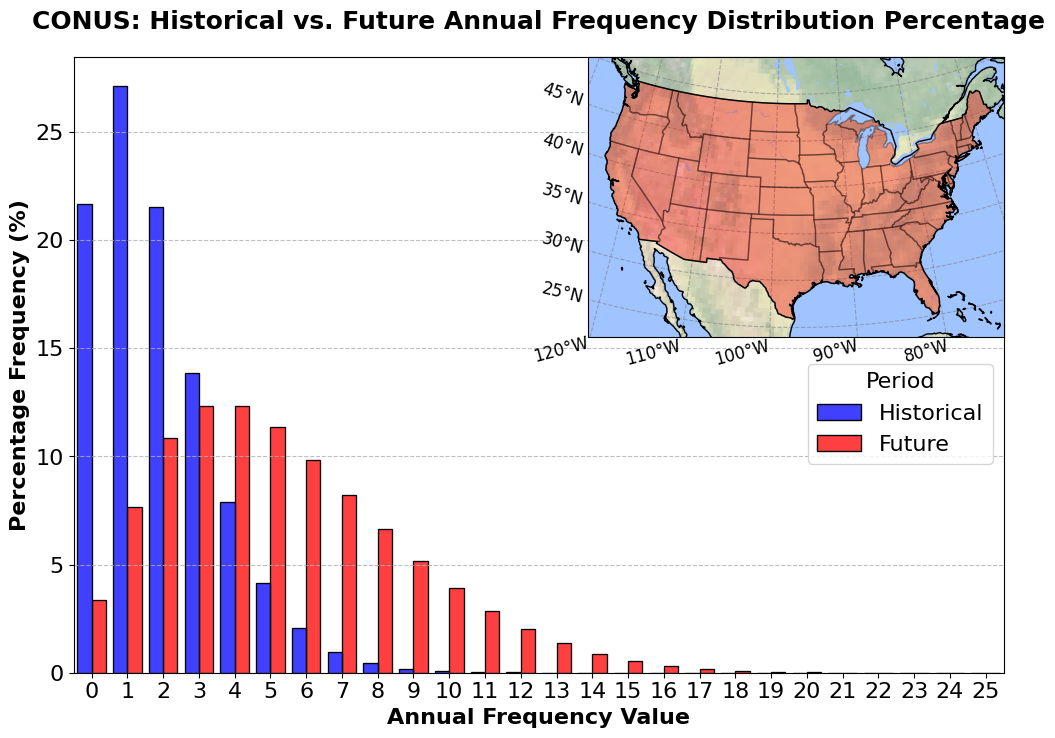

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import seaborn as sns

# Capture the figure object
fig = plt.figure(figsize=(12, 8))

# 4. Create the plot and capture the Axes object
ax = sns.histplot(
    data=df_combined,
    x="annual_frequency",
    hue="Period",
    stat="percent",
    discrete=True,
    common_norm=False,
    multiple="dodge",
    palette={"Historical": "blue", "Future": "red"},
    edgecolor="black",
    shrink=0.8,
)

# Set axis tick label sizes to 16
ax.tick_params(axis="both", which="major", labelsize=16)

# Formatting
plt.xlim(-0.5, max_val + 0.5)
plt.xticks(range(0, max_val + 1))

plt.xlabel("Annual Frequency Value", fontsize=16, fontweight="bold")
plt.ylabel("Percentage Frequency (%)", fontsize=16, fontweight="bold")
plt.title(
    "CONUS: Historical vs. Future Annual Frequency Distribution Percentage",
    fontsize=18,
    fontweight="bold",
    pad=20,
)
plt.grid(axis="y", linestyle="--", alpha=0.8)

# =========================================================================
# MOVE LEGEND
# =========================================================================
sns.move_legend(
    ax,
    loc="upper right",
    bbox_to_anchor=(1, 0.52),
    fontsize=16,
    title_fontsize=16,
    frameon=True,
)

# =========================================================================
# ADD CONUS MAP INSET
# =========================================================================
map_crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

ax_inset = fig.add_axes([0.552, 0.53, 0.35, 0.35], projection=map_crs, zorder=5)

# Set spatial boundaries (expanded slightly to show Mexico & Canada clearly)
ax_inset.set_extent([-121, -73, 24, 52], crs=ccrs.PlateCarree())

# 1. Base Stock Image
ax_inset.stock_img()

# 2. Blue Water Overlays
ax_inset.add_feature(
    cfeature.OCEAN.with_scale("50m"), facecolor="#a0c4ff", zorder=2
)
ax_inset.add_feature(
    cfeature.LAKES.with_scale("50m"), facecolor="#a0c4ff", zorder=2
)

# 3. CONUS-ONLY RED TINT
# Load administrative boundaries and filter strictly for US CONUS states
shpfilename = shpreader.natural_earth(
    resolution="50m", category="cultural", name="admin_1_states_provinces_lakes"
)
reader = shpreader.Reader(shpfilename)

conus_geometries = [
    state.geometry
    for state in reader.records()
    if state.attributes["admin"] == "United States of America"
    and state.attributes["postal"] not in ["AK", "HI", "PR", "VI", "GU", "MP", "AS"]
]

# Add red fill ONLY to CONUS states
ax_inset.add_geometries(
    conus_geometries,
    crs=ccrs.PlateCarree(),
    facecolor="red",
    edgecolor="black",
    linewidth=1,
    alpha=0.35,  # Red tint transparency
    zorder=3,
)

# # 4. State/Province Lines for Canada, Mexico, and USA (unfilled outlines)
# all_states = cfeature.NaturalEarthFeature(
#     category="cultural",
#     name="admin_1_states_provinces_lakes",
#     scale="50m",
#     facecolor="none",
#     edgecolor="black",
#     linewidth=0.5,
#     alpha=0.5,
#     zorder=4,
# )
# ax_inset.add_feature(all_states)

# 5. Country Boundaries with Black Borders
countries = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_0_boundary_lines_land",
    scale="50m",
    facecolor="none",
    edgecolor="black",
    linewidth=1,
    zorder=4,
)
ax_inset.add_feature(countries)

# 6. Coastlines
ax_inset.add_feature(
    cfeature.COASTLINE.with_scale("50m"),
    edgecolor="black",
    linewidth=1,
    zorder=4,
)

# 7. Gridlines
gl = ax_inset.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.8,
    color="gray",
    alpha=0.6,
    linestyle="--",
    zorder=5,
)

# Restrict labels to ONLY the bottom and left
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

gl.x_inline = False
gl.y_inline = False

gl.xpadding = 4  
gl.ypadding = 4  

# Style the labels
gl.xlabel_style = {'size': 12, 'color': 'black', 'rotation': 15}
gl.ylabel_style = {'size': 12, 'color': 'black'}

# Force clean tick intervals
gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

plt.savefig('annual_frq_CONUS', dpi=300, bbox_inches='tight')
plt.show()

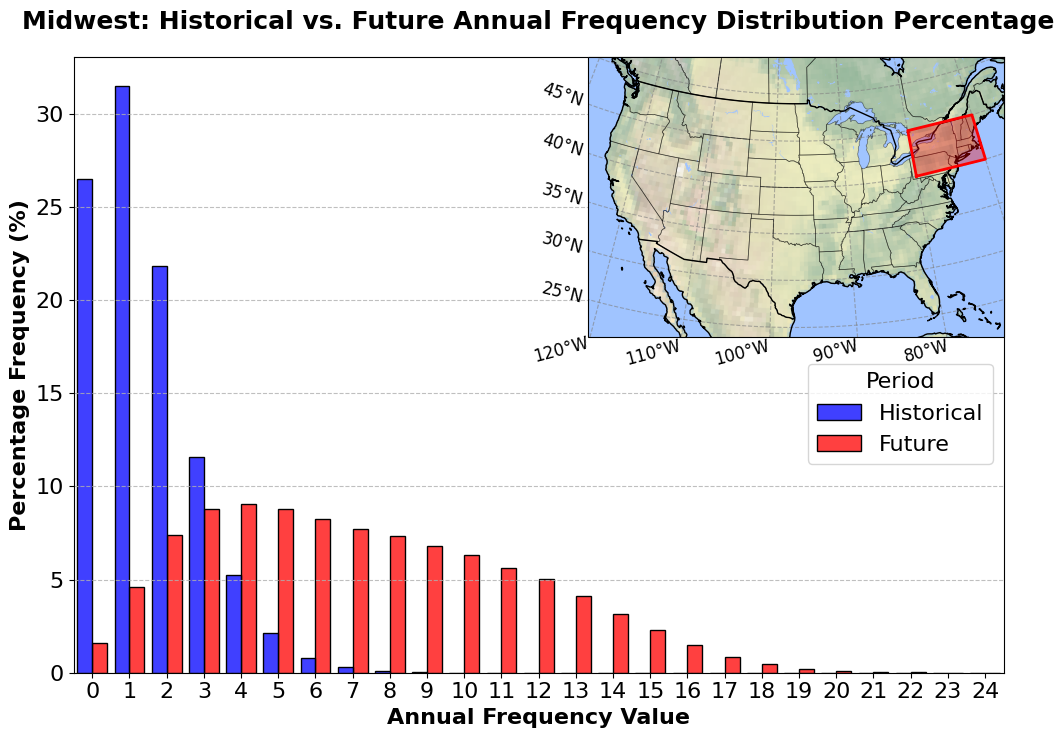

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# =========================================================================
# STEP C: Slice CONUS-Masked Data for the Target Lat/Lon Region
# Region Bounding Box: N=47, S=39, W=103°W (-103), E=89°W (-89)
# =========================================================================
lat_s, lat_n = 40, 45
lon_w, lon_e = -80, -70


def slice_spatial_box(df, s=lat_s, n=lat_n, w=lon_w, e=lon_e):
    """Filter dataframe by latitude and longitude bounds.

    Handles both [-180, 180] and [0, 360] longitude conventions.
    """
    w_neg, e_neg = -abs(w), -abs(e)  # Western hemisphere negative format
    w_360, e_360 = w_neg % 360, e_neg % 360  # 0-360 degrees format

    lat_mask = (df["lat"] >= s) & (df["lat"] <= n)
    lon_mask = ((df["lon"] >= w_neg) & (df["lon"] <= e_neg)) | (
        (df["lon"] >= w_360) & (df["lon"] <= e_360)
    )

    return df[lat_mask & lon_mask].copy()


# 1. Slice historical and future CONUS masked DataFrames for the specified region
df_frq_yearly_hist_sub = slice_spatial_box(
    df_frq_yearly_hist_conus, s=lat_s, n=lat_n, w=lon_w, e=lon_e
)
df_frq_yearly_ftr_sub = slice_spatial_box(
    df_frq_yearly_ftr_conus, s=lat_s, n=lat_n, w=lon_w, e=lon_e
)

# 2. Add period identifier
df_frq_yearly_hist_sub["Period"] = "Historical"
df_frq_yearly_ftr_sub["Period"] = "Future"

# 3. Combine into a single regional DataFrame
df_combined_sub = pd.concat(
    [df_frq_yearly_hist_sub, df_frq_yearly_ftr_sub], ignore_index=True
)

# 4. Recalculate maximum value for x-axis scaling
max_val = int(df_combined_sub["annual_frequency"].max())

# =========================================================================
# STEP D: Histogram Plotting with Region Inset Map
# =========================================================================
fig = plt.figure(figsize=(12, 8))

# Create histogram plot
ax = sns.histplot(
    data=df_combined_sub,
    x="annual_frequency",
    hue="Period",
    stat="percent",
    discrete=True,
    common_norm=False,
    multiple="dodge",
    palette={"Historical": "blue", "Future": "red"},
    edgecolor="black",
    shrink=0.8,
)

# Set tick sizes and ranges
ax.tick_params(axis="both", which="major", labelsize=16)
plt.xlim(-0.5, max_val + 0.5)
plt.xticks(range(0, max_val + 1))

# Formatting labels and title
plt.xlabel("Annual Frequency Value", fontsize=16, fontweight="bold")
plt.ylabel("Percentage Frequency (%)", fontsize=16, fontweight="bold")
plt.title(
    "Midwest: Historical vs. Future Annual Frequency Distribution Percentage",
    fontsize=18,
    fontweight="bold",
    pad=20,
)
plt.grid(axis="y", linestyle="--", alpha=0.8)

# =========================================================================
# MOVE LEGEND
# =========================================================================
sns.move_legend(
    ax,
    loc="upper right",
    bbox_to_anchor=(1, 0.52),
    fontsize=16,
    title_fontsize=16,
    frameon=True,
)

# =========================================================================
# ADD CONUS MAP INSET WITH REGIONAL BOUNDING BOX
# =========================================================================
map_crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

ax_inset = fig.add_axes([0.552, 0.53, 0.35, 0.35], projection=map_crs, zorder=5)

# CONUS Spatial extent
ax_inset.set_extent([-121, -73, 24, 52], crs=ccrs.PlateCarree())

# 1. Base Stock Image
ax_inset.stock_img()

# 2. Blue Water Overlays
ax_inset.add_feature(
    cfeature.OCEAN.with_scale("50m"), facecolor="#a0c4ff", zorder=2
)
ax_inset.add_feature(
    cfeature.LAKES.with_scale("50m"), facecolor="#a0c4ff", zorder=2
)

# 3. DRAW TRANSLUCENT RED BOUNDING BOX
box_lons = [lon_w, lon_e, lon_e, lon_w, lon_w]
box_lats = [lat_s, lat_s, lat_n, lat_n, lat_s]

# Fill interior with transparent red
ax_inset.fill(
    box_lons,
    box_lats,
    color="red",
    alpha=0.35,
    transform=ccrs.PlateCarree(),
    zorder=6,
)

# Draw solid red boundary line around the box
ax_inset.plot(
    box_lons,
    box_lats,
    color="red",
    linewidth=2,
    linestyle="-",
    transform=ccrs.PlateCarree(),
    zorder=7,
)

# 4. State/Province Lines for Canada, Mexico, and USA
all_states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lakes",
    scale="50m",
    facecolor="none",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.5,
    zorder=3,
)
ax_inset.add_feature(all_states)

# 5. Country Boundaries with Black Borders
countries = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_0_boundary_lines_land",
    scale="50m",
    facecolor="none",
    edgecolor="black",
    linewidth=1,
    zorder=4,
)
ax_inset.add_feature(countries)

# 6. Coastlines
ax_inset.add_feature(
    cfeature.COASTLINE.with_scale("50m"),
    edgecolor="black",
    linewidth=1,
    zorder=4,
)

# 7. Gridlines
gl = ax_inset.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.8,
    color="gray",
    alpha=0.6,
    linestyle="--",
    zorder=5,
)

# Restrict labels to ONLY the bottom and left
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

gl.x_inline = False
gl.y_inline = False

gl.xpadding = 4  
gl.ypadding = 4  

# Style the labels
gl.xlabel_style = {'size': 12, 'color': 'black', 'rotation': 15}
gl.ylabel_style = {'size': 12, 'color': 'black'}

# Force clean tick intervals
gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

plt.savefig('annual_frq_MIDWEST', dpi=300, bbox_inches='tight')
plt.show()

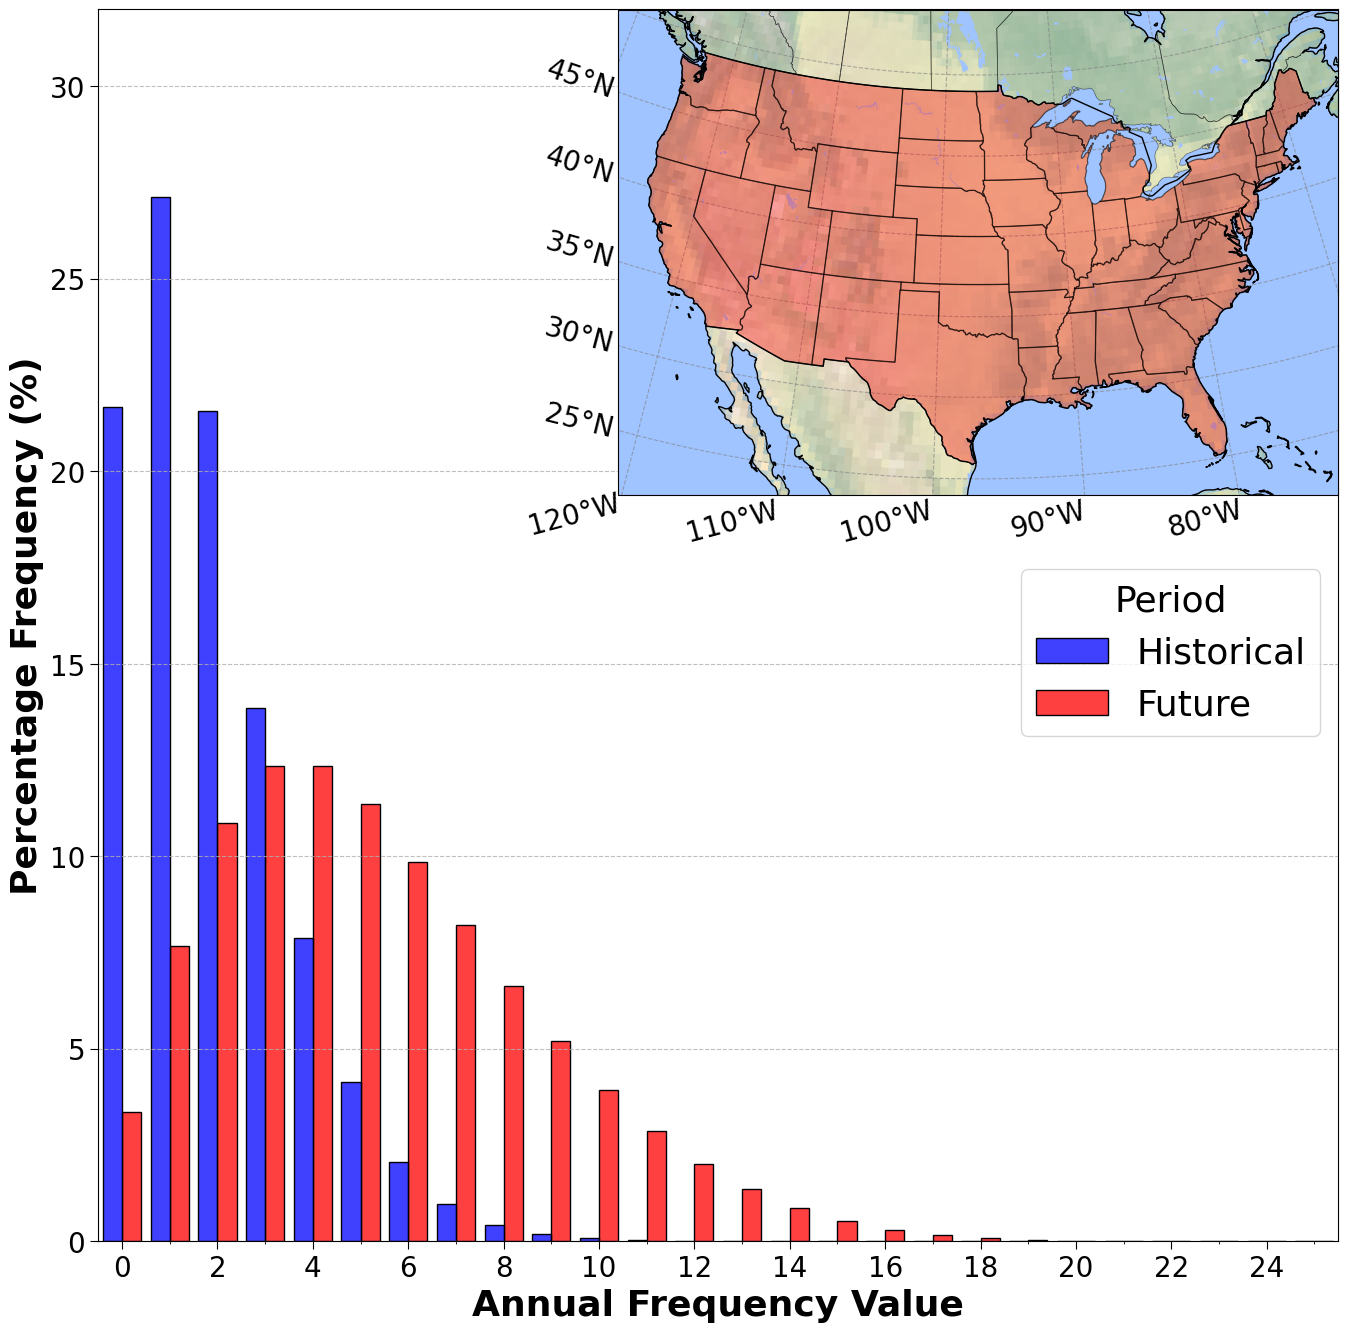

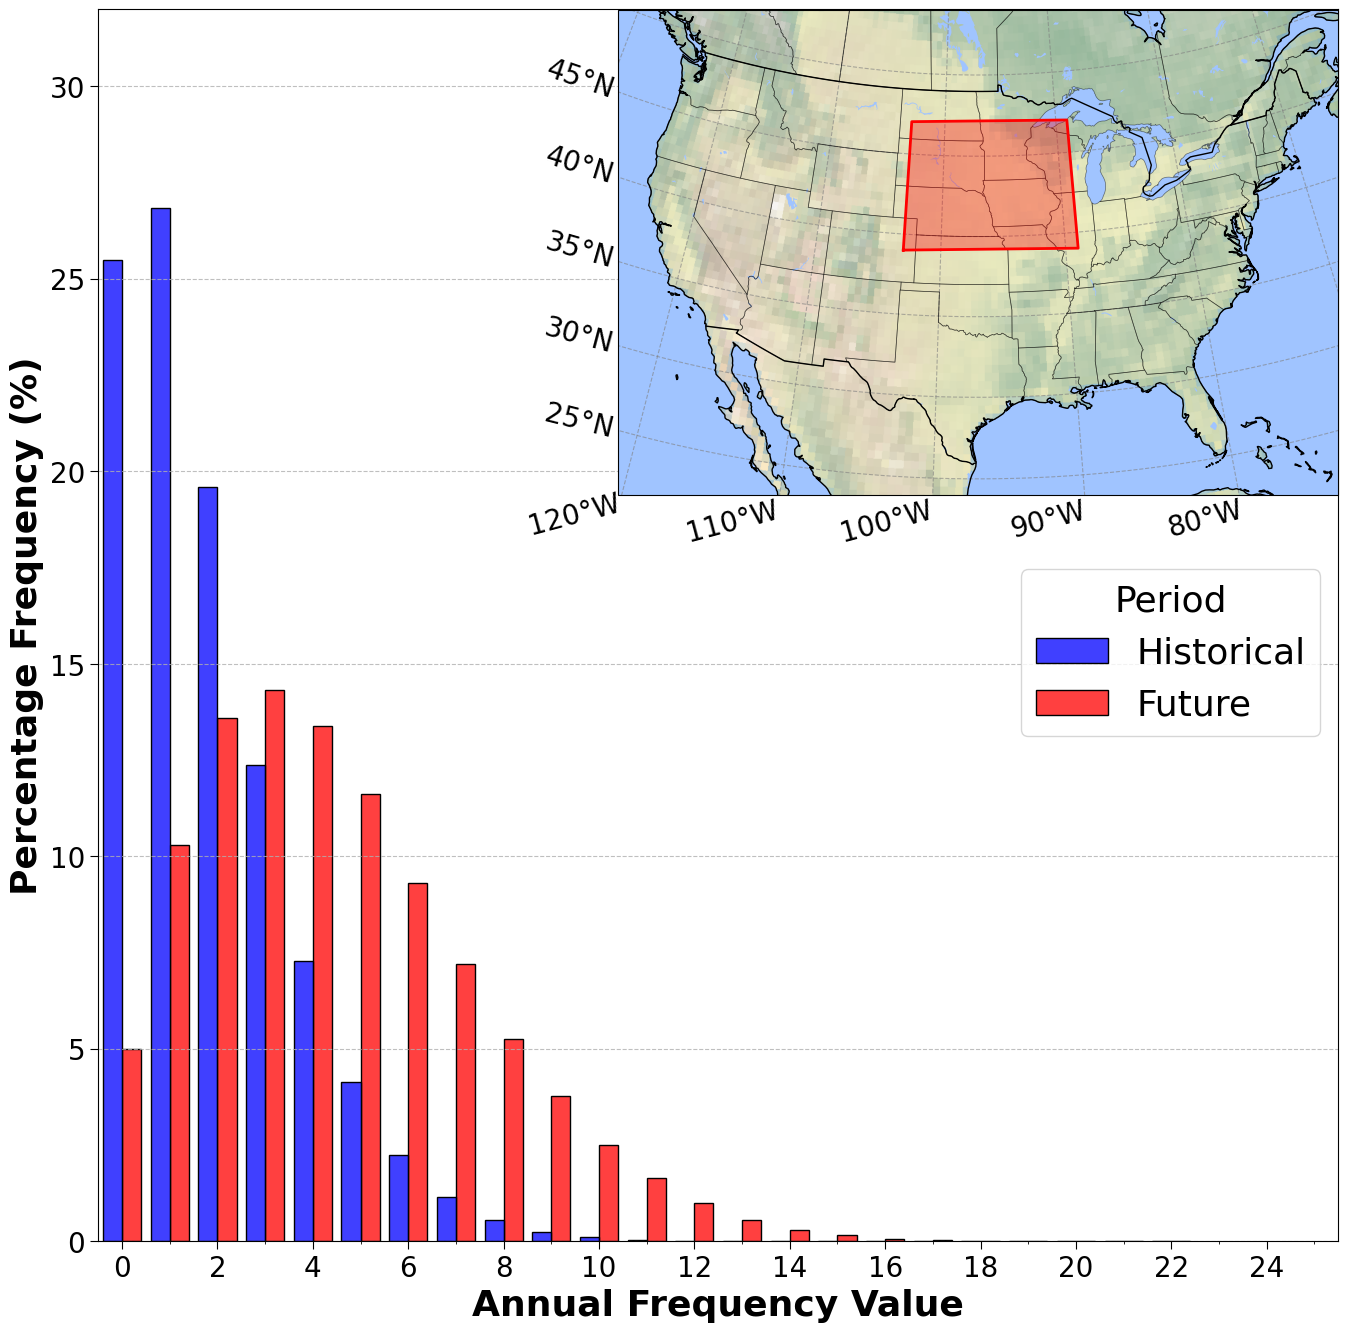

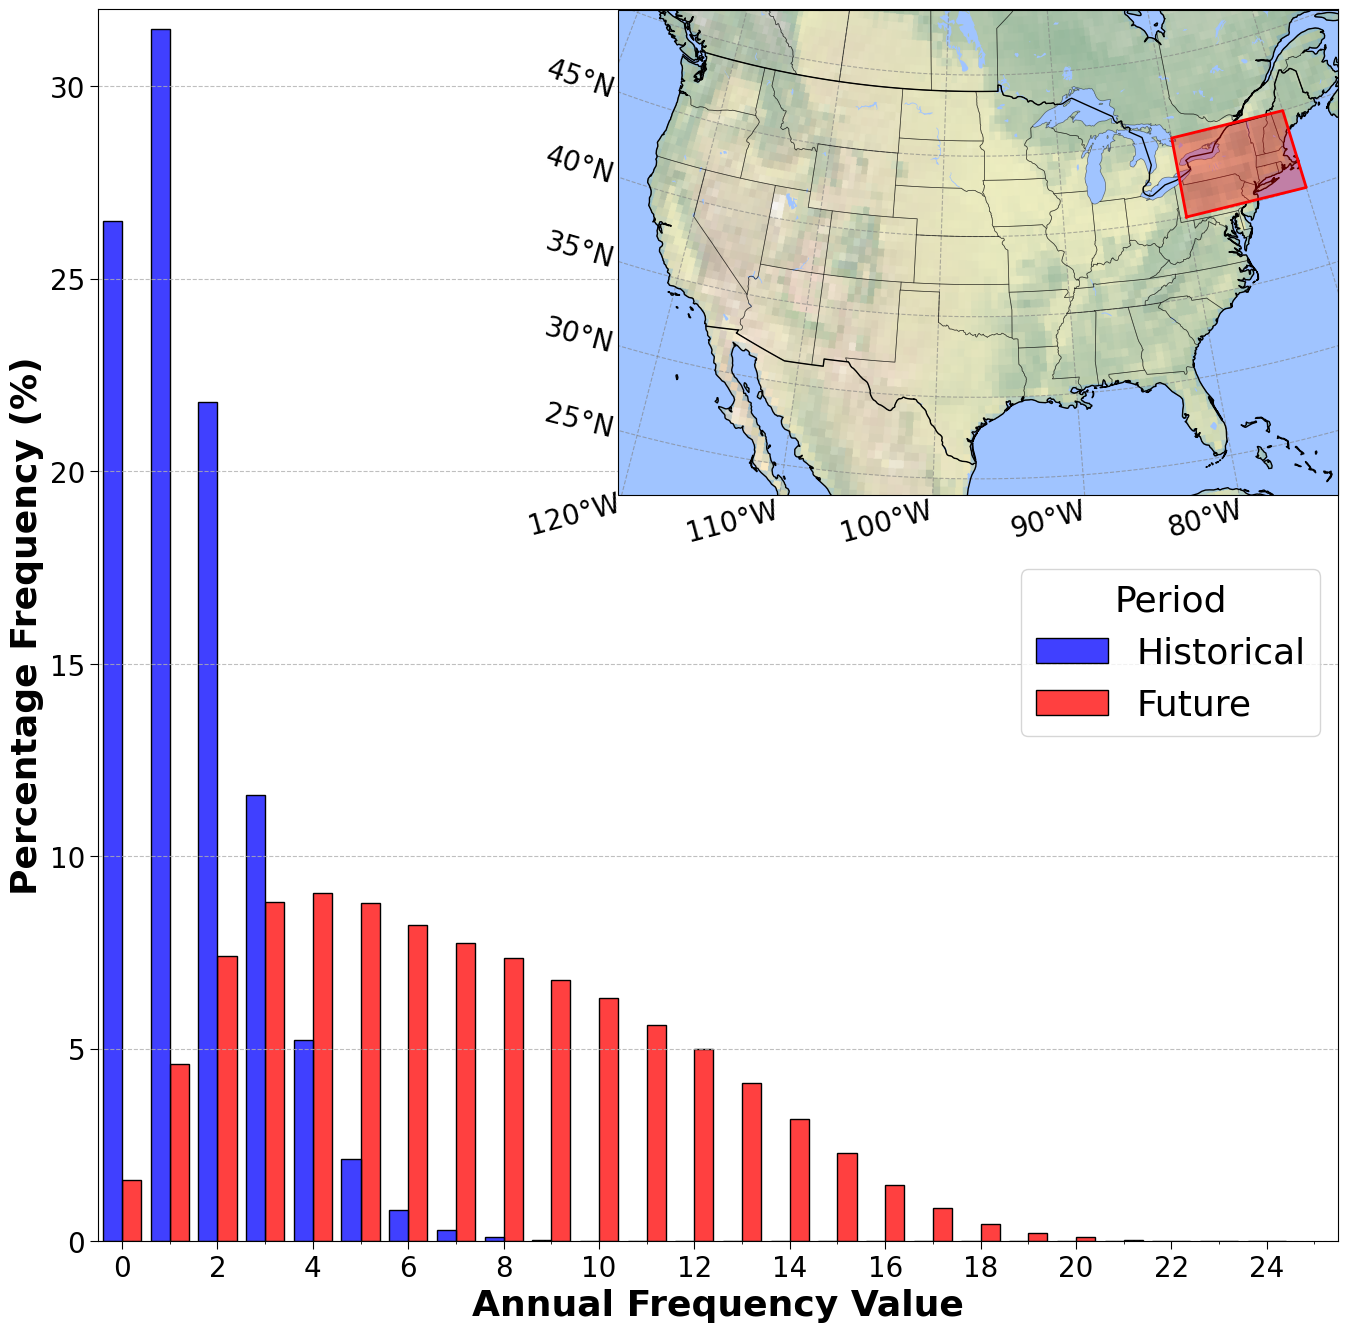

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import seaborn as sns

# =========================================================================
# 1. DEFINE REGIONS CONFIGURATION (Discrete Integer Frequency)
# =========================================================================
regions = [
    {
        "name": "CONUS",
        "save_name": "annual_frq_CONUS.png",
        "title": "CONUS: Historical vs. Future Annual Frequency Distribution Percentage",
        "is_conus": True,
        "lat_s": None,
        "lat_n": None,
        "lon_w": None,
        "lon_e": None,
    },
    {
        "name": "Midwest",
        "save_name": "annual_frq_MIDWEST.png",
        "title": "Midwest: Historical vs. Future Annual Frequency Distribution Percentage",
        "is_conus": False,
        "lat_s": 39,
        "lat_n": 47,
        "lon_w": -103,
        "lon_e": -89,
    },
    {
        "name": "Northeast",
        "save_name": "annual_frq_NE.png",
        "title": "Northeast: Historical vs. Future Annual Frequency Distribution Percentage",
        "is_conus": False,
        "lat_s": 40,
        "lat_n": 45,
        "lon_w": -80,
        "lon_e": -70,
    },
]


def slice_spatial_box(df, s=None, n=None, w=None, e=None):
    """Filter dataframe by latitude and longitude bounds.

    Returns full DataFrame if bounds are None (e.g. for CONUS).
    """
    if s is None or n is None or w is None or e is None:
        return df.copy()

    w_neg, e_neg = -abs(w), -abs(e)
    w_360, e_360 = w_neg % 360, e_neg % 360

    lat_mask = (df["lat"] >= s) & (df["lat"] <= n)
    lon_mask = ((df["lon"] >= w_neg) & (df["lon"] <= e_neg)) | (
        (df["lon"] >= w_360) & (df["lon"] <= e_360)
    )

    return df[lat_mask & lon_mask].copy()


# =========================================================================
# 2. PRE-PROCESS DATA & CALCULATE GLOBAL MAX LIMITS
# =========================================================================
processed_regions = []
global_max_x = 0
global_max_y = 0

# Cache CONUS geometry once for the CONUS inset map
shpfilename = shpreader.natural_earth(
    resolution="50m", category="cultural", name="admin_1_states_provinces_lakes"
)
reader = shpreader.Reader(shpfilename)
conus_geometries = [
    state.geometry
    for state in reader.records()
    if state.attributes["admin"] == "United States of America"
    and state.attributes["postal"]
    not in ["AK", "HI", "PR", "VI", "GU", "MP", "AS"]
]

for reg in regions:
    # Slice data for the region (or return full set if CONUS)
    df_hist = slice_spatial_box(
        df_frq_yearly_hist_conus,
        reg["lat_s"],
        reg["lat_n"],
        reg["lon_w"],
        reg["lon_e"],
    )
    df_ftr = slice_spatial_box(
        df_frq_yearly_ftr_conus,
        reg["lat_s"],
        reg["lat_n"],
        reg["lon_w"],
        reg["lon_e"],
    )

    df_hist["Period"] = "Historical"
    df_ftr["Period"] = "Future"
    df_combined = pd.concat([df_hist, df_ftr], ignore_index=True)

    # Track maximum x frequency value across ALL regions
    reg_max_x = int(df_combined["annual_frequency"].max())
    if reg_max_x > global_max_x:
        global_max_x = reg_max_x

    # Determine maximum percentage frequency (Y-axis max height)
    for period in ["Historical", "Future"]:
        sub_data = df_combined[df_combined["Period"] == period]["annual_frequency"]
        if len(sub_data) > 0:
            counts = sub_data.value_counts(normalize=True) * 100
            if len(counts) > 0:
                global_max_y = max(global_max_y, counts.max())

    processed_regions.append({**reg, "df_combined": df_combined})

# Calculate standardized integer boundaries across all figures
x_upper_limit = global_max_x
y_upper_limit = (np.ceil(global_max_y / 5) * 5 + 2) - 5 # Padding up to nearest 5%


# =========================================================================
# 3. GENERATE ALL DISCRETE FREQUENCY PLOTS IN LOOP
# =========================================================================
for reg in processed_regions:
    fig = plt.figure(figsize=(16, 16))

    # --- Discrete Histogram Plot ---
    ax = sns.histplot(
        data=reg["df_combined"],
        x="annual_frequency",
        hue="Period",
        stat="percent",
        discrete=True,  # Ensures whole-integer discrete bins
        common_norm=False,
        multiple="dodge",
        palette={"Historical": "blue", "Future": "red"},
        edgecolor="black",
        shrink=0.8,
    )

    # Integer Tick Locators (Major ticks = 1 integer step)
    ax.xaxis.set_major_locator(MultipleLocator(2.0))
    ax.xaxis.set_minor_locator(MultipleLocator(1.0))

    ax.tick_params(axis="both", which="major", labelsize=20, length=6)

    # Set exact x/y limits using global max values
    plt.xlim(-0.5, x_upper_limit + 0.5)
    plt.ylim(0, y_upper_limit)

    # Labels and Title
    plt.xlabel("Annual Frequency Value", fontsize=26, fontweight="bold")
    plt.ylabel("Percentage Frequency (%)", fontsize=26, fontweight="bold")
    plt.grid(axis="y", linestyle="--", alpha=0.8)

    # Move Legend
    sns.move_legend(
        ax,
        loc="upper right",
        bbox_to_anchor=(1, 0.56),
        fontsize=26,
        title_fontsize=26,
        frameon=True,
    )

    # --- Add Cartopy Inset Map ---
    map_crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)
    ax_inset = fig.add_axes([0.45, 0.503, 0.45, 0.45], projection=map_crs, zorder=5)
    ax_inset.set_extent([-121, -73, 24, 52], crs=ccrs.PlateCarree())

    ax_inset.stock_img()
    ax_inset.add_feature(
        cfeature.OCEAN.with_scale("50m"), facecolor="#a0c4ff", zorder=2
    )
    ax_inset.add_feature(
        cfeature.LAKES.with_scale("50m"), facecolor="#a0c4ff", zorder=2
    )

    # Handle inset map highlight: Entire CONUS red vs. Regional Box
    if reg["is_conus"]:
        ax_inset.add_geometries(
            conus_geometries,
            crs=ccrs.PlateCarree(),
            facecolor="red",
            edgecolor="black",
            linewidth=1,
            alpha=0.35,
            zorder=3,
        )
    else:
        box_lons = [
            reg["lon_w"],
            reg["lon_e"],
            reg["lon_e"],
            reg["lon_w"],
            reg["lon_w"],
        ]
        box_lats = [
            reg["lat_s"],
            reg["lat_s"],
            reg["lat_n"],
            reg["lat_n"],
            reg["lat_s"],
        ]

        ax_inset.fill(
            box_lons,
            box_lats,
            color="red",
            alpha=0.35,
            transform=ccrs.PlateCarree(),
            zorder=6,
        )
        ax_inset.plot(
            box_lons,
            box_lats,
            color="red",
            linewidth=2,
            linestyle="-",
            transform=ccrs.PlateCarree(),
            zorder=7,
        )

    # Cartopy Features & Borders
    all_states = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_1_states_provinces_lakes",
        scale="50m",
        facecolor="none",
        edgecolor="black",
        linewidth=0.5,
        alpha=0.5,
        zorder=3,
    )
    ax_inset.add_feature(all_states)

    countries = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_0_boundary_lines_land",
        scale="50m",
        facecolor="none",
        edgecolor="black",
        linewidth=1,
        zorder=4,
    )
    ax_inset.add_feature(countries)
    ax_inset.add_feature(
        cfeature.COASTLINE.with_scale("50m"),
        edgecolor="black",
        linewidth=1,
        zorder=4,
    )

    gl = ax_inset.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.8,
        color="gray",
        alpha=0.6,
        linestyle="--",
        zorder=5,
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.x_inline = False
    gl.y_inline = False
    gl.xpadding = 4
    gl.ypadding = 4
    gl.xlabel_style = {"size": 20, "color": "black", "rotation": 15}
    gl.ylabel_style = {"size": 20, "color": "black"}
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    plt.savefig(reg["save_name"], dpi=300, bbox_inches="tight")
    plt.show()